In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet


In [53]:
test = pd.to_datetime(pd.read_csv('../../sample_submission.csv')['Date'])


In [54]:
test


0     2023-01-01
1     2023-01-02
2     2023-01-03
3     2023-01-04
4     2023-01-05
         ...    
543   2024-06-27
544   2024-06-28
545   2024-06-29
546   2024-06-30
547   2024-07-01
Name: Date, Length: 548, dtype: datetime64[ns]

# Tạo các đặc trưng Seasonality từ Prophet

## a. Huấn luyện Prophet

In [55]:
train = pd.read_csv('../../sales.csv')
train['Date'] = pd.to_datetime(train['Date'])
train = train[train['Date'] >= '2019-01-01']
train


,Date,Revenue,COGS
2372,2019-01-01,2430742.10,2422276.45
2373,2019-01-02,857486.80,611460.51
2374,2019-01-03,1095516.84,931676.57
2375,2019-01-04,1356732.44,1032253.29
2376,2019-01-05,1752585.71,1344358.95
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [56]:
test = pd.read_csv('../../sample_submission.csv')
test['Date'] = pd.to_datetime(test['Date'])
test.drop(['Revenue','COGS'],axis=1,inplace=True)
test


,Date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
543,2024-06-27
544,2024-06-28
545,2024-06-29
546,2024-06-30


In [57]:
test = test.rename(columns={'Date': 'ds'})


In [58]:
test


,ds
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
543,2024-06-27
544,2024-06-28
545,2024-06-29
546,2024-06-30


In [59]:
train_cogs = train[['Date','COGS']].rename(columns={'Date':'ds','COGS':'y'})
train_rev = train[['Date','Revenue']].rename(columns={'Date':'ds','Revenue':'y'})


In [60]:
cogs_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
cogs_model.fit(train_cogs)


21:56:54 - cmdstanpy - INFO - Chain [1] start processing
21:56:54 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
#COGS Forecast
future = pd.concat([train_cogs[['ds']], test[['ds']]])
cogs_forecast = cogs_model.predict(future)


In [62]:
features = cogs_forecast[['ds', 'trend', 'weekly', 'yearly']]


In [63]:
cogs_train = train.merge(features,right_on='ds', left_on='Date', how='left')
cogs_test  = test.merge(features, on='ds')


In [64]:
cogs_train.drop(['Revenue','ds'], axis=1, inplace=True)
cogs_train


,Date,COGS,trend,weekly,yearly
0,2019-01-01,2422276.45,2.820162e+06,35829.888159,-937202.098246
1,2019-01-02,611460.51,2.819447e+06,223085.939261,-948149.891712
2,2019-01-03,931676.57,2.818732e+06,145508.403989,-962262.612919
3,2019-01-04,1032253.29,2.818017e+06,-144975.150278,-979399.254753
4,2019-01-05,1344358.95,2.817302e+06,-224433.722346,-999347.874602
...,...,...,...,...,...
1456,2022-12-27,2184872.24,2.863993e+06,35829.888159,-930334.097338
1457,2022-12-28,3513621.00,2.864487e+06,223085.939261,-925575.448577
1458,2022-12-29,3170787.10,2.864981e+06,145508.403989,-923756.258829
1459,2022-12-30,3022292.15,2.865475e+06,-144975.150279,-925026.917537


In [65]:
cogs_test


,ds,trend,weekly,yearly
0,2023-01-01,2.866464e+06,-84717.609113,-937202.098246
1,2023-01-02,2.866958e+06,49702.250328,-948149.891712
2,2023-01-03,2.867452e+06,35829.888159,-962262.612919
3,2023-01-04,2.867946e+06,223085.939261,-979399.254753
4,2023-01-05,2.868440e+06,145508.403989,-999347.874602
...,...,...,...,...
543,2024-06-27,3.134748e+06,145508.403989,610403.109521
544,2024-06-28,3.135242e+06,-144975.150279,589698.923393
545,2024-06-29,3.135736e+06,-224433.722346,571662.138318
546,2024-06-30,3.136230e+06,-84717.609113,556130.617224


In [66]:
cogs_test.to_csv('cogs_test_prophet.csv', index=False)
cogs_train.to_csv('cogs_train_prophet.csv', index=False)


In [67]:
rev_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
rev_model.fit(train_rev)


21:56:54 - cmdstanpy - INFO - Chain [1] start processing
21:56:54 - cmdstanpy - INFO - Chain [1] done processing


In [68]:
#Revenue Forecast
future = pd.concat([train_rev[['ds']], test[['ds']]])
rev_forecast = rev_model.predict(future)


In [69]:
features = rev_forecast[['ds', 'trend', 'weekly', 'yearly']]


In [70]:
rev_train = train.merge(features,right_on='ds', left_on='Date', how='left')
rev_test  = test.merge(features, on='ds')


In [71]:
rev_train.drop(['COGS','ds'], axis=1, inplace=True)


In [72]:
rev_train


,Date,Revenue,trend,weekly,yearly
0,2019-01-01,2430742.10,3.176800e+06,39168.888926,-1.218772e+06
1,2019-01-02,857486.80,3.176150e+06,251394.748486,-1.214545e+06
2,2019-01-03,1095516.84,3.175500e+06,161942.333884,-1.212811e+06
3,2019-01-04,1356732.44,3.174849e+06,-163636.183708,-1.213503e+06
4,2019-01-05,1752585.71,3.174199e+06,-261953.262148,-1.216493e+06
...,...,...,...,...,...
1456,2022-12-27,2100553.66,3.254388e+06,39168.888926,-1.275944e+06
1457,2022-12-28,3448729.20,3.254968e+06,251394.748486,-1.260062e+06
1458,2022-12-29,3083944.33,3.255547e+06,161942.333883,-1.246257e+06
1459,2022-12-30,2884668.76,3.256126e+06,-163636.183708,-1.234693e+06


In [73]:
rev_test


,ds,trend,weekly,yearly
0,2023-01-01,3.257285e+06,-97740.859863,-1.218772e+06
1,2023-01-02,3.257864e+06,70824.334423,-1.214545e+06
2,2023-01-03,3.258443e+06,39168.888926,-1.212811e+06
3,2023-01-04,3.259022e+06,251394.748486,-1.213503e+06
4,2023-01-05,3.259602e+06,161942.333884,-1.216493e+06
...,...,...,...,...
543,2024-06-27,3.571818e+06,161942.333883,4.047993e+05
544,2024-06-28,3.572397e+06,-163636.183708,3.455264e+05
545,2024-06-29,3.572977e+06,-261953.262148,2.937903e+05
546,2024-06-30,3.573556e+06,-97740.859863,2.497912e+05


In [74]:
rev_test.to_csv('rev_test_prophet.csv', index=False)
rev_train.to_csv('rev_train_prophet.csv', index=False)


## b. Trích xuất các đặc trưng : doy, month, year

In [75]:
rev_test.rename(columns={'ds':'Date'},inplace=True)
cogs_test.rename(columns={'ds':'Date'},inplace=True)


In [76]:
rev_test


,Date,trend,weekly,yearly
0,2023-01-01,3.257285e+06,-97740.859863,-1.218772e+06
1,2023-01-02,3.257864e+06,70824.334423,-1.214545e+06
2,2023-01-03,3.258443e+06,39168.888926,-1.212811e+06
3,2023-01-04,3.259022e+06,251394.748486,-1.213503e+06
4,2023-01-05,3.259602e+06,161942.333884,-1.216493e+06
...,...,...,...,...
543,2024-06-27,3.571818e+06,161942.333883,4.047993e+05
544,2024-06-28,3.572397e+06,-163636.183708,3.455264e+05
545,2024-06-29,3.572977e+06,-261953.262148,2.937903e+05
546,2024-06-30,3.573556e+06,-97740.859863,2.497912e+05


In [77]:
dfs = [rev_train, cogs_train, rev_test, cogs_test]  # thay bằng tên của bạn

for df in dfs:
    df['Date'] = pd.to_datetime(df['Date'])
    df['doy'] = df['Date'].dt.dayofyear
    df['dow'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year


In [78]:
rev_train


,Date,Revenue,trend,weekly,yearly,doy,dow,month,year
0,2019-01-01,2430742.10,3.176800e+06,39168.888926,-1.218772e+06,1,1,1,2019
1,2019-01-02,857486.80,3.176150e+06,251394.748486,-1.214545e+06,2,2,1,2019
2,2019-01-03,1095516.84,3.175500e+06,161942.333884,-1.212811e+06,3,3,1,2019
3,2019-01-04,1356732.44,3.174849e+06,-163636.183708,-1.213503e+06,4,4,1,2019
4,2019-01-05,1752585.71,3.174199e+06,-261953.262148,-1.216493e+06,5,5,1,2019
...,...,...,...,...,...,...,...,...,...
1456,2022-12-27,2100553.66,3.254388e+06,39168.888926,-1.275944e+06,361,1,12,2022
1457,2022-12-28,3448729.20,3.254968e+06,251394.748486,-1.260062e+06,362,2,12,2022
1458,2022-12-29,3083944.33,3.255547e+06,161942.333883,-1.246257e+06,363,3,12,2022
1459,2022-12-30,2884668.76,3.256126e+06,-163636.183708,-1.234693e+06,364,4,12,2022


In [79]:
rev_train.to_csv('rev_train_prophet_seasonality.csv', index=False)
rev_test.to_csv('rev_test_prophet_seasonality.csv', index=False)
cogs_train.to_csv('cogs_train_prophet_seasonality.csv', index=False)
cogs_test.to_csv('cogs_test_prophet_seasonality.csv', index=False)


In [80]:
X_rev_train = rev_train.drop(['Revenue'], axis=1)
y_rev_train = rev_train['Revenue']


In [81]:
X_cogs_train = cogs_train.drop(['COGS'], axis=1)
y_cogs_train = cogs_train['COGS']


In [82]:
X_rev_train


,Date,trend,weekly,yearly,doy,dow,month,year
0,2019-01-01,3.176800e+06,39168.888926,-1.218772e+06,1,1,1,2019
1,2019-01-02,3.176150e+06,251394.748486,-1.214545e+06,2,2,1,2019
2,2019-01-03,3.175500e+06,161942.333884,-1.212811e+06,3,3,1,2019
3,2019-01-04,3.174849e+06,-163636.183708,-1.213503e+06,4,4,1,2019
4,2019-01-05,3.174199e+06,-261953.262148,-1.216493e+06,5,5,1,2019
...,...,...,...,...,...,...,...,...
1456,2022-12-27,3.254388e+06,39168.888926,-1.275944e+06,361,1,12,2022
1457,2022-12-28,3.254968e+06,251394.748486,-1.260062e+06,362,2,12,2022
1458,2022-12-29,3.255547e+06,161942.333883,-1.246257e+06,363,3,12,2022
1459,2022-12-30,3.256126e+06,-163636.183708,-1.234693e+06,364,4,12,2022


In [83]:
X_rev_train['Date'] = pd.to_datetime(X_rev_train['Date'])
X_cogs_train['Date'] = pd.to_datetime(X_cogs_train['Date'])


In [84]:
X_rev_train.drop(['Date'], axis=1, inplace=True)
X_cogs_train.drop(['Date'], axis=1, inplace=True)


In [85]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
rev_model = XGBRegressor()
rev_model.fit(X_rev_train, y_rev_train)
rev_pred = rev_model.predict(X_rev_train)
rev_mae = mean_absolute_error(y_rev_train, rev_pred)
print(f'MAE for Revenue: {rev_mae}')


MAE for Revenue: 120040.10522672825


In [86]:
import joblib
joblib.dump(rev_model, 'rev_model_prophet_seasonality.pkl')


['rev_model_prophet_seasonality.pkl']

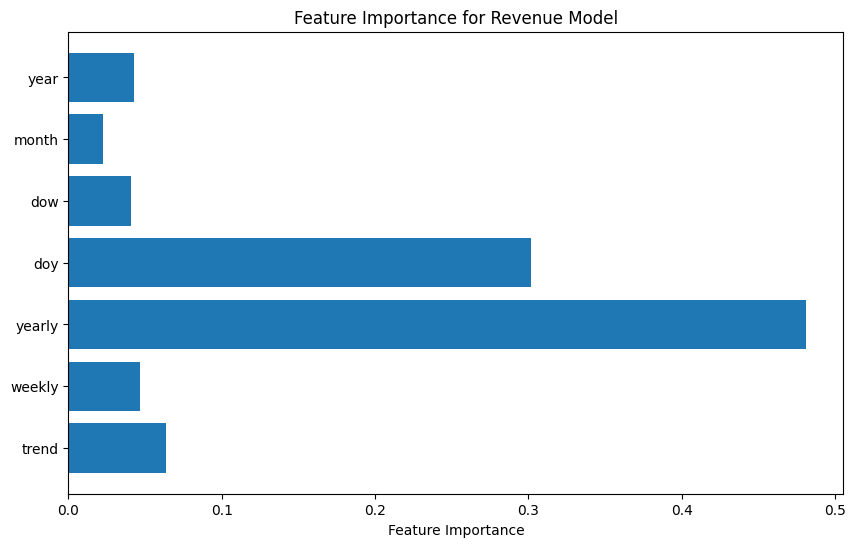

In [87]:
# feature importance
import matplotlib.pyplot as plt
importances = rev_model.feature_importances_
feature_names = X_rev_train.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Revenue Model')
plt.show()


## COGS_model

In [89]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
cogs_model = XGBRegressor()
cogs_model.fit(X_cogs_train, y_cogs_train)
cogs_pred = cogs_model.predict(X_cogs_train)
cogs_mae = mean_absolute_error(y_cogs_train, cogs_pred)
print(f'MAE for COGS: {cogs_mae}')


MAE for COGS: 109928.41582991103


In [90]:
import joblib
joblib.dump(cogs_model, 'cogs_model_prophet_seasonality.pkl')


['cogs_model_prophet_seasonality.pkl']